# TC-GPA: Label-Flipping-Robust Histopathology Classification

Run the cells in order. The notebook automatically detects the NCT-CRC-HE-100K folder under `/kaggle/input`, creates a stratified 70/15/15 split, flips 30% of training labels, trains EfficientNet-B0 with TC-GPA, and saves all tables, metrics, and figures to `/kaggle/working/tc_gpa_outputs`.

In [1]:
!pip install -q --upgrade sympy

In [2]:
import torch
import torchvision
import sympy

print(torch.__version__)
print(torchvision.__version__)
print(sympy.__version__)

2.10.0+cu128
0.25.0+cu128
1.14.0


In [3]:
"""
TC-GPA: Temporal Counterfactual Gradient–Prototype Agreement
End-to-end PyTorch pipeline for robust histopathology classification under
30% symmetric class-stratified label flipping.

Expected dataset layout:
    DATASET_ROOT/
        ADI/
        BACK/
        DEB/
        LYM/
        MUC/
        MUS/
        NORM/
        STR/
        TUM/

The script auto-detects the NCT-CRC-HE-100K root under /kaggle/input.
It also supports JPG, JPEG, PNG, BMP, TIF, and TIFF through PIL.
"""

# =============================================================================
# SECTION 1 — Imports, configuration, reproducibility, and output directories
# =============================================================================

import os
import gc
import json
import math
import random
import warnings
from copy import deepcopy
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile

from sklearn.metrics import (
    accuracy_score,
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize, StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

warnings.filterwarnings("ignore", category=UserWarning)
ImageFile.LOAD_TRUNCATED_IMAGES = True


@dataclass
class Config:
    # Dataset and experiment settings
    kaggle_input_root: str = "/kaggle/input/datasets/imrankhan77/nct-crc-he-100k"
    dataset_root: Optional[str] = None  # Keep None for automatic detection.
    output_dir: str = "/kaggle/working/tc_gpa_outputs"
    expected_crc_classes: Tuple[str, ...] = (
        "ADI", "BACK", "DEB", "LYM", "MUC", "MUS", "NORM", "STR", "TUM"
    )
    image_extensions: Tuple[str, ...] = (
        ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"
    )

    # Reproducibility and split
    seed: int = 7
    train_fraction: float = 0.70
    validation_fraction: float = 0.15
    test_fraction: float = 0.15
    label_flip_rate: float = 0.30

    # Image and loader settings
    image_size: int = 224
    resize_size: int = 256
    batch_size: int = 64
    num_workers: int = 2
    pin_memory: bool = True

    # Model settings
    pretrained: bool = True
    feature_dim: int = 128
    dropout: float = 0.20

    # Optimization settings
    warmup_epochs: int = 5
    refinement_epochs: int = 12
    frozen_epochs: int = 2
    update_interval: int = 2
    head_learning_rate: float = 3e-4
    backbone_learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    gradient_clip_norm: float = 5.0
    early_stopping_patience: int = 6
    use_amp: bool = True

    # TC-GPA settings
    alpha_gradient: float = 0.50
    beta_feature: float = 0.30
    gamma_probability: float = 0.20
    temporal_margin_decay: float = 0.80
    temporal_probability_decay: float = 0.80
    minimum_anchor_count: int = 20
    anchor_fraction: float = 0.30
    minimum_temporal_updates_for_correction: int = 2
    noise_probability_threshold: float = 0.50
    gmm_reg_covar: float = 1e-4


CFG = Config()


def set_global_seed(seed: int) -> None:
    """Set all relevant random seeds and deterministic flags."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_global_seed(CFG.seed)

OUTPUT_DIR = Path(CFG.output_dir)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = bool(CFG.use_amp and DEVICE.type == "cuda")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")
print(f"Automatic mixed precision: {AMP_ENABLED}")

with open(OUTPUT_DIR / "configuration.json", "w", encoding="utf-8") as file:
    json.dump(asdict(CFG), file, indent=2)



PyTorch version: 2.10.0+cu128
Device: cuda
Automatic mixed precision: True


In [4]:
# =============================================================================
# SECTION 2 — Dataset discovery, file indexing, and stratified 70/15/15 split
# =============================================================================


def directory_contains_expected_classes(directory: Path, classes: Sequence[str]) -> bool:
    """Return True when all expected class folders exist directly inside directory."""
    if not directory.is_dir():
        return False
    child_names = {child.name for child in directory.iterdir() if child.is_dir()}
    return set(classes).issubset(child_names)


def find_dataset_root(cfg: Config) -> Path:
    """Find the NCT-CRC-HE-100K directory automatically or use an explicit path."""
    if cfg.dataset_root is not None:
        explicit_root = Path(cfg.dataset_root)
        if not directory_contains_expected_classes(explicit_root, cfg.expected_crc_classes):
            raise FileNotFoundError(
                f"The configured dataset root does not contain all expected class folders: {explicit_root}"
            )
        return explicit_root

    search_root = Path(cfg.kaggle_input_root)
    if not search_root.exists():
        raise FileNotFoundError(
            f"Kaggle input directory was not found: {search_root}. "
            "Set CFG.dataset_root to the dataset folder."
        )

    # Search a limited depth first because Kaggle datasets are usually shallow.
    candidates = [search_root]
    candidates.extend([p for p in search_root.glob("*/*") if p.is_dir()])
    candidates.extend([p for p in search_root.glob("*/*/*") if p.is_dir()])

    for candidate in candidates:
        if directory_contains_expected_classes(candidate, cfg.expected_crc_classes):
            return candidate

    # Full fallback search.
    for current_root, directory_names, _ in os.walk(search_root):
        if set(cfg.expected_crc_classes).issubset(set(directory_names)):
            return Path(current_root)

    raise FileNotFoundError(
        "Could not locate a directory containing the nine expected CRC class folders. "
        "Set CFG.dataset_root manually if your folder names or structure differ."
    )


def collect_image_paths(
    dataset_root: Path,
    class_names: Sequence[str],
    valid_extensions: Sequence[str],
) -> Tuple[np.ndarray, np.ndarray, Dict[str, int]]:
    """Collect image paths and integer labels from class subdirectories."""
    class_to_index = {class_name: index for index, class_name in enumerate(class_names)}
    image_paths: List[str] = []
    integer_labels: List[int] = []

    extension_set = {extension.lower() for extension in valid_extensions}

    for class_name in class_names:
        class_directory = dataset_root / class_name
        class_files = sorted(
            str(path)
            for path in class_directory.rglob("*")
            if path.is_file() and path.suffix.lower() in extension_set
        )
        if not class_files:
            raise RuntimeError(f"No supported image files were found in {class_directory}")

        image_paths.extend(class_files)
        integer_labels.extend([class_to_index[class_name]] * len(class_files))

    return (
        np.asarray(image_paths, dtype=object),
        np.asarray(integer_labels, dtype=np.int64),
        class_to_index,
    )


def stratified_train_validation_test_split(
    paths: np.ndarray,
    labels: np.ndarray,
    cfg: Config,
) -> Dict[str, np.ndarray]:
    """Create stratified 70% train, 15% validation, and 15% test partitions."""
    total_fraction = cfg.train_fraction + cfg.validation_fraction + cfg.test_fraction
    if not np.isclose(total_fraction, 1.0):
        raise ValueError("Train, validation, and test fractions must sum to 1.0.")

    all_indices = np.arange(len(paths))
    held_out_fraction = cfg.validation_fraction + cfg.test_fraction

    train_indices, held_out_indices = train_test_split(
        all_indices,
        test_size=held_out_fraction,
        random_state=cfg.seed,
        shuffle=True,
        stratify=labels,
    )

    validation_share_of_held_out = cfg.validation_fraction / held_out_fraction
    validation_indices, test_indices = train_test_split(
        held_out_indices,
        train_size=validation_share_of_held_out,
        random_state=cfg.seed,
        shuffle=True,
        stratify=labels[held_out_indices],
    )

    return {
        "train_indices": np.asarray(train_indices, dtype=np.int64),
        "validation_indices": np.asarray(validation_indices, dtype=np.int64),
        "test_indices": np.asarray(test_indices, dtype=np.int64),
    }


def build_split_count_table(
    train_labels: np.ndarray,
    validation_labels: np.ndarray,
    test_labels: np.ndarray,
    class_names: Sequence[str],
) -> pd.DataFrame:
    """Create a class-wise table of train, validation, and test counts."""
    rows = []
    for class_index, class_name in enumerate(class_names):
        rows.append(
            {
                "Class": class_name,
                "Train": int(np.sum(train_labels == class_index)),
                "Validation": int(np.sum(validation_labels == class_index)),
                "Test": int(np.sum(test_labels == class_index)),
            }
        )
    table = pd.DataFrame(rows).set_index("Class")
    table.loc["TOTAL"] = table.sum(axis=0)
    return table


DATASET_ROOT = find_dataset_root(CFG)
CLASS_NAMES = list(CFG.expected_crc_classes)
NUM_CLASSES = len(CLASS_NAMES)

ALL_PATHS, ALL_LABELS, CLASS_TO_INDEX = collect_image_paths(
    DATASET_ROOT,
    CLASS_NAMES,
    CFG.image_extensions,
)

SPLIT = stratified_train_validation_test_split(ALL_PATHS, ALL_LABELS, CFG)

TRAIN_PATHS = ALL_PATHS[SPLIT["train_indices"]]
TRAIN_CLEAN_LABELS = ALL_LABELS[SPLIT["train_indices"]]
VALIDATION_PATHS = ALL_PATHS[SPLIT["validation_indices"]]
VALIDATION_LABELS = ALL_LABELS[SPLIT["validation_indices"]]
TEST_PATHS = ALL_PATHS[SPLIT["test_indices"]]
TEST_LABELS = ALL_LABELS[SPLIT["test_indices"]]

SPLIT_COUNTS = build_split_count_table(
    TRAIN_CLEAN_LABELS,
    VALIDATION_LABELS,
    TEST_LABELS,
    CLASS_NAMES,
)

print(f"\nDetected dataset root: {DATASET_ROOT}")
print(f"Total supported images: {len(ALL_PATHS):,}")
print("\nClass-wise train/validation/test counts:")
print(SPLIT_COUNTS)
SPLIT_COUNTS.to_csv(OUTPUT_DIR / "split_class_counts.csv")




Detected dataset root: /kaggle/input/datasets/imrankhan77/nct-crc-he-100k/NCT-CRC-HE-100K
Total supported images: 100,000

Class-wise train/validation/test counts:
       Train  Validation   Test
Class                          
ADI     7285        1561   1561
BACK    7396        1585   1585
DEB     8059        1727   1726
LYM     8090        1733   1734
MUC     6227        1334   1335
MUS     9475        2031   2030
NORM    6134        1314   1315
STR     7312        1567   1567
TUM    10022        2148   2147
TOTAL  70000       15000  15000


In [5]:
# =============================================================================
# SECTION 3 — Exact 30% class-stratified symmetric label flipping on training data
# =============================================================================


def proportional_flip_counts(labels: np.ndarray, rate: float, num_classes: int) -> np.ndarray:
    """
    Allocate an exact global flip budget proportionally across classes using
    the largest-remainder method.
    """
    class_counts = np.bincount(labels, minlength=num_classes)
    exact_allocations = class_counts.astype(np.float64) * rate
    allocations = np.floor(exact_allocations).astype(np.int64)

    target_total = int(round(len(labels) * rate))
    remaining = target_total - int(allocations.sum())

    if remaining > 0:
        fractional_parts = exact_allocations - allocations
        order = np.argsort(-fractional_parts)
        for class_index in order[:remaining]:
            allocations[class_index] += 1

    if allocations.sum() != target_total:
        raise RuntimeError("Failed to allocate the exact label-flip budget.")
    if np.any(allocations > class_counts):
        raise RuntimeError("A class was assigned more flips than available samples.")

    return allocations


def apply_symmetric_class_stratified_label_flipping(
    clean_labels: np.ndarray,
    flip_rate: float,
    num_classes: int,
    seed: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Flip exactly the requested fraction of training labels. Samples are selected
    proportionally from each source class, and every selected label is replaced
    uniformly by one of the other classes.
    """
    if not 0.0 <= flip_rate < 1.0:
        raise ValueError("flip_rate must be in [0, 1).")
    if num_classes < 2:
        raise ValueError("At least two classes are required for label flipping.")

    rng = np.random.default_rng(seed)
    noisy_labels = clean_labels.copy()
    flip_mask = np.zeros(len(clean_labels), dtype=bool)
    class_flip_allocations = proportional_flip_counts(clean_labels, flip_rate, num_classes)

    for source_class in range(num_classes):
        source_indices = np.flatnonzero(clean_labels == source_class)
        number_to_flip = int(class_flip_allocations[source_class])
        selected_indices = rng.choice(source_indices, size=number_to_flip, replace=False)

        # Draw from [0, num_classes-2] and shift values at or above source_class.
        replacement_labels = rng.integers(0, num_classes - 1, size=number_to_flip)
        replacement_labels = replacement_labels + (replacement_labels >= source_class)

        noisy_labels[selected_indices] = replacement_labels
        flip_mask[selected_indices] = True

    flipped_indices = np.flatnonzero(flip_mask)

    if len(flipped_indices) != int(round(len(clean_labels) * flip_rate)):
        raise RuntimeError("The number of flipped samples does not match the exact target.")
    if np.any(noisy_labels[flipped_indices] == clean_labels[flipped_indices]):
        raise RuntimeError("At least one selected sample was not assigned a different label.")

    return noisy_labels, flip_mask, flipped_indices


def build_flip_statistics(
    clean_labels: np.ndarray,
    noisy_labels: np.ndarray,
    flip_mask: np.ndarray,
    class_names: Sequence[str],
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Create class-wise before/after counts and a complete flip transition matrix."""
    num_classes = len(class_names)
    before_counts = np.bincount(clean_labels, minlength=num_classes)
    after_counts = np.bincount(noisy_labels, minlength=num_classes)

    transition = confusion_matrix(
        clean_labels,
        noisy_labels,
        labels=np.arange(num_classes),
    )
    transition_table = pd.DataFrame(
        transition,
        index=[f"Original_{name}" for name in class_names],
        columns=[f"Assigned_{name}" for name in class_names],
    )

    rows = []
    for class_index, class_name in enumerate(class_names):
        source_mask = clean_labels == class_index
        flipped_out = int(np.sum(source_mask & flip_mask))
        unchanged = int(np.sum(source_mask & (~flip_mask)))
        received_from_other_classes = int(
            np.sum((noisy_labels == class_index) & (clean_labels != class_index))
        )
        rows.append(
            {
                "Class": class_name,
                "Training images before flipping": int(before_counts[class_index]),
                "Labels flipped out of this class": flipped_out,
                "Labels received from other classes": received_from_other_classes,
                "Unchanged labels": unchanged,
                "Training images after flipping": int(after_counts[class_index]),
            }
        )

    summary_table = pd.DataFrame(rows).set_index("Class")
    summary_table.loc["TOTAL"] = summary_table.sum(axis=0)
    return summary_table, transition_table


TRAIN_NOISY_LABELS, TRUE_FLIP_MASK, FLIPPED_TRAIN_INDICES = (
    apply_symmetric_class_stratified_label_flipping(
        TRAIN_CLEAN_LABELS,
        CFG.label_flip_rate,
        NUM_CLASSES,
        CFG.seed,
    )
)

FLIP_SUMMARY, FLIP_TRANSITION = build_flip_statistics(
    TRAIN_CLEAN_LABELS,
    TRAIN_NOISY_LABELS,
    TRUE_FLIP_MASK,
    CLASS_NAMES,
)

actual_flip_rate = float(TRUE_FLIP_MASK.mean())
print(f"\nRequested training-label flip rate: {CFG.label_flip_rate:.2%}")
print(f"Actual training-label flip rate:    {actual_flip_rate:.2%}")
print(f"Number of flipped training samples: {int(TRUE_FLIP_MASK.sum()):,}")
print("\nClass-wise training counts before and after flipping:")
print(FLIP_SUMMARY)
print("\nLabel transition matrix (rows=clean/original, columns=assigned/noisy):")
print(FLIP_TRANSITION)

FLIP_SUMMARY.to_csv(OUTPUT_DIR / "training_flip_summary.csv")
FLIP_TRANSITION.to_csv(OUTPUT_DIR / "training_flip_transition_matrix.csv")

flip_audit = pd.DataFrame(
    {
        "image_path": TRAIN_PATHS,
        "clean_label_index": TRAIN_CLEAN_LABELS,
        "clean_label": [CLASS_NAMES[index] for index in TRAIN_CLEAN_LABELS],
        "assigned_training_label_index": TRAIN_NOISY_LABELS,
        "assigned_training_label": [CLASS_NAMES[index] for index in TRAIN_NOISY_LABELS],
        "was_flipped": TRUE_FLIP_MASK.astype(int),
    }
)
flip_audit.to_csv(OUTPUT_DIR / "training_label_flip_audit.csv", index=False)




Requested training-label flip rate: 30.00%
Actual training-label flip rate:    30.00%
Number of flipped training samples: 21,000

Class-wise training counts before and after flipping:
       Training images before flipping  Labels flipped out of this class  \
Class                                                                      
ADI                               7285                              2185   
BACK                              7396                              2219   
DEB                               8059                              2418   
LYM                               8090                              2427   
MUC                               6227                              1868   
MUS                               9475                              2842   
NORM                              6134                              1840   
STR                               7312                              2194   
TUM                              10022                 

In [6]:
# =============================================================================
# SECTION 4 — Scientifically moderate augmentation, datasets, and data loaders
# =============================================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

TRAIN_TRANSFORM = transforms.Compose(
    [
        transforms.Resize((CFG.resize_size, CFG.resize_size)),
        transforms.RandomCrop((CFG.image_size, CFG.image_size)),
        transforms.RandomHorizontalFlip(p=0.50),
        transforms.RandomVerticalFlip(p=0.50),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.08, contrast=0.08),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

EVALUATION_TRANSFORM = transforms.Compose(
    [
        transforms.Resize((CFG.resize_size, CFG.resize_size)),
        transforms.CenterCrop((CFG.image_size, CFG.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)


def load_rgb_image(path: str) -> Image.Image:
    """Load any supported image with PIL and force three-channel RGB format."""
    with Image.open(path) as image:
        return image.convert("RGB")


class SoftLabelImageDataset(Dataset):
    """
    Training dataset that returns augmented images, updateable soft targets,
    the current hard/noisy label, and the stable sample index.
    """

    def __init__(
        self,
        paths: np.ndarray,
        hard_labels: np.ndarray,
        num_classes: int,
        transform,
    ) -> None:
        self.paths = np.asarray(paths, dtype=object)
        self.hard_labels = np.asarray(hard_labels, dtype=np.int64)
        self.num_classes = int(num_classes)
        self.transform = transform
        self.soft_targets = np.eye(self.num_classes, dtype=np.float32)[self.hard_labels]

    def update_soft_targets(self, new_targets: np.ndarray) -> None:
        """Replace training targets after validating shape and probability sums."""
        new_targets = np.asarray(new_targets, dtype=np.float32)
        expected_shape = (len(self.paths), self.num_classes)
        if new_targets.shape != expected_shape:
            raise ValueError(
                f"Soft-target shape {new_targets.shape} does not match {expected_shape}."
            )
        if not np.all(np.isfinite(new_targets)):
            raise ValueError("Soft targets contain NaN or infinite values.")
        if np.any(new_targets < -1e-6):
            raise ValueError("Soft targets contain negative probabilities.")
        if not np.allclose(new_targets.sum(axis=1), 1.0, atol=1e-4):
            raise ValueError("Every soft target must sum to 1.0.")
        self.soft_targets = new_targets

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, index: int):
        image = load_rgb_image(str(self.paths[index]))
        image = self.transform(image)
        soft_target = torch.from_numpy(self.soft_targets[index].copy()).float()
        hard_label = int(self.hard_labels[index])
        return image, soft_target, hard_label, index


class IndexedHardLabelDataset(Dataset):
    """
    Deterministic dataset for validation, testing, and ordered feature extraction.
    """

    def __init__(self, paths: np.ndarray, labels: np.ndarray, transform) -> None:
        self.paths = np.asarray(paths, dtype=object)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, index: int):
        image = load_rgb_image(str(self.paths[index]))
        image = self.transform(image)
        return image, int(self.labels[index]), index


TRAIN_DATASET = SoftLabelImageDataset(
    TRAIN_PATHS,
    TRAIN_NOISY_LABELS,
    NUM_CLASSES,
    TRAIN_TRANSFORM,
)

TRAIN_ANALYSIS_DATASET = IndexedHardLabelDataset(
    TRAIN_PATHS,
    TRAIN_NOISY_LABELS,
    EVALUATION_TRANSFORM,
)

VALIDATION_DATASET = IndexedHardLabelDataset(
    VALIDATION_PATHS,
    VALIDATION_LABELS,
    EVALUATION_TRANSFORM,
)

TEST_DATASET = IndexedHardLabelDataset(
    TEST_PATHS,
    TEST_LABELS,
    EVALUATION_TRANSFORM,
)


def seed_worker(worker_id: int) -> None:
    """Seed NumPy and Python inside each DataLoader worker."""
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


LOADER_GENERATOR = torch.Generator()
LOADER_GENERATOR.manual_seed(CFG.seed)

COMMON_LOADER_ARGUMENTS = {
    "batch_size": CFG.batch_size,
    "num_workers": CFG.num_workers,
    "pin_memory": bool(CFG.pin_memory and DEVICE.type == "cuda"),
    "worker_init_fn": seed_worker,
    "generator": LOADER_GENERATOR,
    "persistent_workers": False,  # Required so updated soft targets reach workers.
}

TRAIN_LOADER = DataLoader(
    TRAIN_DATASET,
    shuffle=True,
    drop_last=False,
    **COMMON_LOADER_ARGUMENTS,
)

TRAIN_ANALYSIS_LOADER = DataLoader(
    TRAIN_ANALYSIS_DATASET,
    shuffle=False,
    drop_last=False,
    **COMMON_LOADER_ARGUMENTS,
)

VALIDATION_LOADER = DataLoader(
    VALIDATION_DATASET,
    shuffle=False,
    drop_last=False,
    **COMMON_LOADER_ARGUMENTS,
)

TEST_LOADER = DataLoader(
    TEST_DATASET,
    shuffle=False,
    drop_last=False,
    **COMMON_LOADER_ARGUMENTS,
)

print("\nDataLoaders created successfully.")
print(f"Training batches:   {len(TRAIN_LOADER):,}")
print(f"Validation batches: {len(VALIDATION_LOADER):,}")
print(f"Test batches:       {len(TEST_LOADER):,}")




DataLoaders created successfully.
Training batches:   1,094
Validation batches: 235
Test batches:       235


In [7]:
# =============================================================================
# SECTION 5 — Lightweight EfficientNet-B0 model with a 128-D gradient head
# =============================================================================


class LightweightEfficientNet(nn.Module):
    """
    EfficientNet-B0 feature extractor followed by a compact 128-D projection
    and a linear classifier. The projection output is used by TC-GPA.
    """

    def __init__(
        self,
        num_classes: int,
        feature_dim: int,
        dropout: float,
        pretrained: bool,
    ) -> None:
        super().__init__()

        weights = None
        if pretrained:
            try:
                weights = EfficientNet_B0_Weights.DEFAULT
                backbone = efficientnet_b0(weights=weights)
            except Exception as exception:
                print(
                    "WARNING: ImageNet weights could not be loaded. "
                    f"Falling back to random initialization. Details: {exception}"
                )
                backbone = efficientnet_b0(weights=None)
        else:
            backbone = efficientnet_b0(weights=None)

        backbone_output_dim = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()

        self.backbone = backbone
        self.projection = nn.Sequential(
            nn.Linear(backbone_output_dim, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout),
        )
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, images: torch.Tensor, return_features: bool = False):
        backbone_features = self.backbone(images)
        compact_features = self.projection(backbone_features)
        logits = self.classifier(compact_features)
        if return_features:
            return logits, compact_features
        return logits


def set_backbone_trainability(
    model: LightweightEfficientNet,
    mode: str,
) -> None:
    """
    Freeze the complete backbone, unfreeze only the final feature blocks,
    or unfreeze the complete backbone.
    """
    if mode not in {"frozen", "last_blocks", "all"}:
        raise ValueError("mode must be 'frozen', 'last_blocks', or 'all'.")

    for parameter in model.backbone.parameters():
        parameter.requires_grad = mode == "all"

    if mode == "last_blocks":
        for parameter in model.backbone.features[-2:].parameters():
            parameter.requires_grad = True

    for parameter in model.projection.parameters():
        parameter.requires_grad = True
    for parameter in model.classifier.parameters():
        parameter.requires_grad = True


MODEL = LightweightEfficientNet(
    num_classes=NUM_CLASSES,
    feature_dim=CFG.feature_dim,
    dropout=CFG.dropout,
    pretrained=CFG.pretrained,
).to(DEVICE)

set_backbone_trainability(MODEL, mode="frozen")

OPTIMIZER = torch.optim.AdamW(
    [
        {
            "params": MODEL.backbone.parameters(),
            "lr": CFG.backbone_learning_rate,
        },
        {
            "params": list(MODEL.projection.parameters())
            + list(MODEL.classifier.parameters()),
            "lr": CFG.head_learning_rate,
        },
    ],
    weight_decay=CFG.weight_decay,
)

# Reduce the learning rate when validation loss stops improving.
SCHEDULER = torch.optim.lr_scheduler.ReduceLROnPlateau(
    OPTIMIZER,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
)

try:
    GRAD_SCALER = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
except (AttributeError, TypeError):
    GRAD_SCALER = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

print(f"\nModel parameters: {sum(p.numel() for p in MODEL.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in MODEL.parameters() if p.requires_grad):,}")



Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s] 



Model parameters: 4,172,933
Trainable parameters: 165,385


In [8]:
# =============================================================================
# SECTION 6 — Training, validation, checkpointing, and ordered output extraction
# =============================================================================


def autocast_context():
    """Return an AMP context that works across recent PyTorch versions."""
    if hasattr(torch, "amp") and hasattr(torch.amp, "autocast"):
        return torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED)
    return torch.cuda.amp.autocast(enabled=AMP_ENABLED)


def soft_cross_entropy(logits: torch.Tensor, soft_targets: torch.Tensor) -> torch.Tensor:
    """Cross-entropy for probability targets; avoids version-dependent APIs."""
    log_probabilities = F.log_softmax(logits, dim=1)
    per_sample_loss = -(soft_targets * log_probabilities).sum(dim=1)
    return per_sample_loss.mean()


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scaler,
) -> Tuple[float, float]:
    """Train for one epoch and report loss plus accuracy against assigned labels."""
    model.train()

    # Keep frozen BatchNorm layers in evaluation mode so their running
    # statistics are not modified while the corresponding parameters are frozen.
    if hasattr(model, "backbone"):
        for module in model.backbone.modules():
            if isinstance(module, nn.modules.batchnorm._BatchNorm):
                direct_parameters = list(module.parameters(recurse=False))
                if direct_parameters and not any(
                    parameter.requires_grad for parameter in direct_parameters
                ):
                    module.eval()

    running_loss = 0.0
    correct_predictions = 0
    sample_count = 0

    for images, soft_targets, hard_labels, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        soft_targets = soft_targets.to(DEVICE, non_blocking=True)
        hard_labels = hard_labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast_context():
            logits = model(images)
            loss = soft_cross_entropy(logits, soft_targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.gradient_clip_norm)
        scaler.step(optimizer)
        scaler.update()

        batch_size = images.size(0)
        running_loss += float(loss.detach().cpu()) * batch_size
        correct_predictions += int((logits.argmax(dim=1) == hard_labels).sum().item())
        sample_count += batch_size

    return running_loss / sample_count, correct_predictions / sample_count


@torch.inference_mode()
def evaluate_model(
    model: nn.Module,
    loader: DataLoader,
) -> Tuple[float, float, np.ndarray, np.ndarray, np.ndarray]:
    """Evaluate clean hard labels and return ordered labels, predictions, and probabilities."""
    model.eval()
    dataset_size = len(loader.dataset)
    all_labels = np.empty(dataset_size, dtype=np.int64)
    all_predictions = np.empty(dataset_size, dtype=np.int64)
    all_probabilities = np.empty((dataset_size, NUM_CLASSES), dtype=np.float32)

    total_loss = 0.0
    total_samples = 0

    for images, labels, indices in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels_device = labels.to(DEVICE, non_blocking=True)

        with autocast_context():
            logits = model(images)
            loss = F.cross_entropy(logits, labels_device, reduction="sum")
            probabilities = torch.softmax(logits, dim=1)

        batch_indices = indices.numpy()
        batch_probabilities = probabilities.float().cpu().numpy()
        batch_predictions = batch_probabilities.argmax(axis=1)

        all_labels[batch_indices] = labels.numpy()
        all_predictions[batch_indices] = batch_predictions
        all_probabilities[batch_indices] = batch_probabilities

        total_loss += float(loss.cpu())
        total_samples += images.size(0)

    mean_loss = total_loss / total_samples
    accuracy = accuracy_score(all_labels, all_predictions)
    return mean_loss, accuracy, all_labels, all_predictions, all_probabilities


@torch.inference_mode()
def extract_ordered_features_and_probabilities(
    model: nn.Module,
    loader: DataLoader,
    feature_dim: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Extract deterministic compact features and probabilities in dataset order."""
    model.eval()
    dataset_size = len(loader.dataset)
    features = np.empty((dataset_size, feature_dim), dtype=np.float32)
    probabilities = np.empty((dataset_size, NUM_CLASSES), dtype=np.float32)
    observed_labels = np.empty(dataset_size, dtype=np.int64)

    for images, labels, indices in loader:
        images = images.to(DEVICE, non_blocking=True)

        with autocast_context():
            logits, compact_features = model(images, return_features=True)
            batch_probabilities = torch.softmax(logits, dim=1)

        batch_indices = indices.numpy()
        features[batch_indices] = compact_features.float().cpu().numpy()
        probabilities[batch_indices] = batch_probabilities.float().cpu().numpy()
        observed_labels[batch_indices] = labels.numpy()

    return features, probabilities, observed_labels


class EarlyStoppingState:
    """Track the best clean validation loss and stop after sustained non-improvement."""

    def __init__(self, patience: int, checkpoint_path: Path) -> None:
        self.patience = int(patience)
        self.checkpoint_path = checkpoint_path
        self.best_validation_loss = math.inf
        self.bad_epoch_count = 0
        self.best_epoch = -1

    def update(self, validation_loss: float, epoch_number: int, model: nn.Module) -> bool:
        improved = validation_loss < self.best_validation_loss - 1e-6
        if improved:
            self.best_validation_loss = validation_loss
            self.bad_epoch_count = 0
            self.best_epoch = epoch_number
            torch.save(model.state_dict(), self.checkpoint_path)
        else:
            self.bad_epoch_count += 1
        return self.bad_epoch_count >= self.patience


HISTORY: Dict[str, List[float]] = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy_against_assigned_labels": [],
    "validation_loss": [],
    "validation_accuracy": [],
}

CHECKPOINT_PATH = OUTPUT_DIR / "best_tc_gpa_model.pt"
EARLY_STOPPING = EarlyStoppingState(CFG.early_stopping_patience, CHECKPOINT_PATH)


def record_epoch(
    epoch_number: int,
    train_loss: float,
    train_accuracy: float,
    validation_loss: float,
    validation_accuracy: float,
) -> None:
    """Append one epoch to the experiment history and print a concise summary."""
    HISTORY["epoch"].append(epoch_number)
    HISTORY["train_loss"].append(train_loss)
    HISTORY["train_accuracy_against_assigned_labels"].append(train_accuracy)
    HISTORY["validation_loss"].append(validation_loss)
    HISTORY["validation_accuracy"].append(validation_accuracy)

    current_lrs = [group["lr"] for group in OPTIMIZER.param_groups]
    print(
        f"Epoch {epoch_number:02d} | "
        f"Train loss {train_loss:.4f} | "
        f"Train acc* {train_accuracy:.4f} | "
        f"Val loss {validation_loss:.4f} | "
        f"Val acc {validation_accuracy:.4f} | "
        f"LRs {current_lrs}"
    )



In [9]:
# =============================================================================
# SECTION 7 — Warm-up training using only the 30%-flipped assigned labels
# =============================================================================

print("\nStarting warm-up training...")
global_epoch = 0
stop_training = False

for warmup_epoch in range(CFG.warmup_epochs):
    global_epoch += 1

    if warmup_epoch == CFG.frozen_epochs:
        set_backbone_trainability(MODEL, mode="last_blocks")
        print("Unfroze the final two EfficientNet feature blocks.")

    train_loss, train_accuracy = train_one_epoch(
        MODEL,
        TRAIN_LOADER,
        OPTIMIZER,
        GRAD_SCALER,
    )
    validation_loss, validation_accuracy, _, _, _ = evaluate_model(
        MODEL,
        VALIDATION_LOADER,
    )

    SCHEDULER.step(validation_loss)
    record_epoch(
        global_epoch,
        train_loss,
        train_accuracy,
        validation_loss,
        validation_accuracy,
    )

    stop_training = EARLY_STOPPING.update(validation_loss, global_epoch, MODEL)
    if stop_training:
        print("Early stopping was reached during warm-up.")
        break




Starting warm-up training...
Epoch 01 | Train loss 1.4739 | Train acc* 0.6114 | Val loss 0.6315 | Val acc 0.9181 | LRs [0.0001, 0.0003]
Epoch 02 | Train loss 1.4195 | Train acc* 0.6350 | Val loss 0.5702 | Val acc 0.9267 | LRs [0.0001, 0.0003]
Unfroze the final two EfficientNet feature blocks.
Epoch 03 | Train loss 1.4189 | Train acc* 0.6359 | Val loss 0.5329 | Val acc 0.9453 | LRs [0.0001, 0.0003]
Epoch 04 | Train loss 1.3702 | Train acc* 0.6540 | Val loss 0.4806 | Val acc 0.9547 | LRs [0.0001, 0.0003]
Epoch 05 | Train loss 1.3521 | Train acc* 0.6601 | Val loss 0.4856 | Val acc 0.9587 | LRs [0.0001, 0.0003]


In [10]:
# =============================================================================
# SECTION 8 — TC-GPA prototypes, counterfactual scores, temporal statistics, and GMM
# =============================================================================


def safe_l2_normalize(array: np.ndarray, axis: int = 1, epsilon: float = 1e-8) -> np.ndarray:
    """L2-normalize an array without division by zero."""
    norms = np.linalg.norm(array, axis=axis, keepdims=True)
    return array / np.maximum(norms, epsilon)


def select_anchor_indices(
    features: np.ndarray,
    probabilities: np.ndarray,
    observed_labels: np.ndarray,
    class_index: int,
    cfg: Config,
) -> np.ndarray:
    """
    Select low-loss, prediction-consistent anchors for one observed class.
    A deterministic fallback guarantees a usable anchor set.
    """
    class_indices = np.flatnonzero(observed_labels == class_index)
    if len(class_indices) == 0:
        raise RuntimeError(f"Class {class_index} has no training samples.")

    predicted_labels = probabilities.argmax(axis=1)
    class_probabilities = np.clip(
        probabilities[class_indices, class_index],
        1e-8,
        1.0,
    )
    class_losses = -np.log(class_probabilities)

    consistent_mask = predicted_labels[class_indices] == class_index
    consistent_indices = class_indices[consistent_mask]

    desired_anchor_count = max(
        cfg.minimum_anchor_count,
        int(round(cfg.anchor_fraction * len(class_indices))),
    )
    desired_anchor_count = min(desired_anchor_count, len(class_indices))

    if len(consistent_indices) >= cfg.minimum_anchor_count:
        consistent_losses = -np.log(
            np.clip(probabilities[consistent_indices, class_index], 1e-8, 1.0)
        )
        ordered = consistent_indices[np.argsort(consistent_losses)]
        anchors = ordered[: min(desired_anchor_count, len(ordered))]
    else:
        ordered = class_indices[np.argsort(class_losses)]
        anchors = ordered[:desired_anchor_count]

    if len(anchors) == 0:
        raise RuntimeError(f"No anchors could be selected for class {class_index}.")
    return anchors


def build_class_prototypes(
    features: np.ndarray,
    probabilities: np.ndarray,
    observed_labels: np.ndarray,
    cfg: Config,
) -> Tuple[np.ndarray, np.ndarray, Dict[int, int]]:
    """
    Build class feature prototypes and output-layer gradient prototypes from
    high-confidence anchor samples.
    """
    num_samples, feature_dim = features.shape
    del num_samples

    feature_prototypes = np.zeros((NUM_CLASSES, feature_dim), dtype=np.float32)
    gradient_prototypes = np.zeros(
        (NUM_CLASSES, NUM_CLASSES, feature_dim),
        dtype=np.float32,
    )
    anchor_counts: Dict[int, int] = {}

    normalized_features = safe_l2_normalize(features, axis=1)
    identity = np.eye(NUM_CLASSES, dtype=np.float32)

    for class_index in range(NUM_CLASSES):
        anchors = select_anchor_indices(
            features,
            probabilities,
            observed_labels,
            class_index,
            cfg,
        )
        anchor_counts[class_index] = len(anchors)

        feature_prototype = normalized_features[anchors].mean(axis=0)
        feature_prototypes[class_index] = safe_l2_normalize(
            feature_prototype[None, :], axis=1
        )[0]

        residuals = probabilities[anchors] - identity[class_index]
        # Mean of outer products: (number_of_anchors, classes, feature_dim)
        gradient_matrices = residuals[:, :, None] * features[anchors, None, :]
        gradient_prototypes[class_index] = gradient_matrices.mean(axis=0)

    return feature_prototypes, gradient_prototypes, anchor_counts


def compute_counterfactual_compatibility(
    features: np.ndarray,
    probabilities: np.ndarray,
    observed_labels: np.ndarray,
    feature_prototypes: np.ndarray,
    gradient_prototypes: np.ndarray,
    cfg: Config,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, Dict[str, np.ndarray]]:
    """
    Compute TC-GPA compatibility for every sample under every candidate class.
    No sample-wise backward pass is required.
    """
    number_of_samples = len(features)
    epsilon = 1e-8

    # Feature compatibility: cosine between each feature and each class prototype.
    normalized_features = safe_l2_normalize(features, axis=1)
    feature_alignment = normalized_features @ feature_prototypes.T

    # Counterfactual residual V_i(c) = p_i - e_c, shape N x C x C.
    candidate_residuals = np.repeat(
        probabilities[:, None, :],
        NUM_CLASSES,
        axis=1,
    )
    candidate_residuals[:, np.arange(NUM_CLASSES), np.arange(NUM_CLASSES)] -= 1.0

    # Q_c h_i for every sample, candidate class, and output dimension.
    q_times_h = np.einsum(
        "ckd,nd->nck",
        gradient_prototypes,
        features,
        optimize=True,
    )

    gradient_numerators = np.sum(candidate_residuals * q_times_h, axis=2)
    residual_norms = np.linalg.norm(candidate_residuals, axis=2)
    feature_norms = np.linalg.norm(features, axis=1, keepdims=True)
    prototype_norms = np.linalg.norm(
        gradient_prototypes.reshape(NUM_CLASSES, -1),
        axis=1,
    )[None, :]

    gradient_denominators = residual_norms * feature_norms * prototype_norms
    gradient_alignment = gradient_numerators / np.maximum(
        gradient_denominators,
        epsilon,
    )
    gradient_alignment = np.clip(gradient_alignment, -1.0, 1.0)

    compatibility_scores = (
        cfg.alpha_gradient * gradient_alignment
        + cfg.beta_feature * feature_alignment
        + cfg.gamma_probability * probabilities
    )

    row_indices = np.arange(number_of_samples)
    observed_scores = compatibility_scores[row_indices, observed_labels]

    alternative_scores = compatibility_scores.copy()
    alternative_scores[row_indices, observed_labels] = -np.inf
    best_alternative_labels = alternative_scores.argmax(axis=1)
    best_alternative_scores = alternative_scores[
        row_indices,
        best_alternative_labels,
    ]
    margins = best_alternative_scores - observed_scores

    diagnostics = {
        "compatibility_scores": compatibility_scores,
        "gradient_alignment": gradient_alignment,
        "feature_alignment": feature_alignment,
    }
    return margins, best_alternative_labels, observed_scores, diagnostics


class TemporalTCGPAState:
    """Maintain lightweight online temporal statistics for every training sample."""

    def __init__(self, number_of_samples: int, num_classes: int) -> None:
        self.number_of_samples = number_of_samples
        self.num_classes = num_classes
        self.step = 0
        self.ema_margin = np.zeros(number_of_samples, dtype=np.float32)
        self.running_mean = np.zeros(number_of_samples, dtype=np.float32)
        self.running_m2 = np.zeros(number_of_samples, dtype=np.float32)
        self.alternative_counts = np.zeros(
            (number_of_samples, num_classes),
            dtype=np.int16,
        )
        self.probability_ema = np.zeros(
            (number_of_samples, num_classes),
            dtype=np.float32,
        )

    def update(
        self,
        margins: np.ndarray,
        alternative_labels: np.ndarray,
        probabilities: np.ndarray,
        cfg: Config,
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Update EMA margins, online variance, class persistence, and probability EMA."""
        margins = margins.astype(np.float32)
        probabilities = probabilities.astype(np.float32)

        self.step += 1
        if self.step == 1:
            self.ema_margin = margins.copy()
            self.running_mean = margins.copy()
            self.probability_ema = probabilities.copy()
        else:
            self.ema_margin = (
                cfg.temporal_margin_decay * self.ema_margin
                + (1.0 - cfg.temporal_margin_decay) * margins
            )

            delta = margins - self.running_mean
            self.running_mean += delta / self.step
            delta_2 = margins - self.running_mean
            self.running_m2 += delta * delta_2

            self.probability_ema = (
                cfg.temporal_probability_decay * self.probability_ema
                + (1.0 - cfg.temporal_probability_decay) * probabilities
            )

        self.alternative_counts[
            np.arange(self.number_of_samples),
            alternative_labels,
        ] += 1

        persistence = self.alternative_counts.max(axis=1).astype(np.float32) / self.step
        stable_alternative_labels = self.alternative_counts.argmax(axis=1)

        if self.step > 1:
            variance = self.running_m2 / (self.step - 1)
        else:
            variance = np.zeros(self.number_of_samples, dtype=np.float32)

        return persistence, stable_alternative_labels, variance.astype(np.float32)


def class_conditional_gmm_noise_probabilities(
    ema_margin: np.ndarray,
    persistence: np.ndarray,
    temporal_variance: np.ndarray,
    observed_labels: np.ndarray,
    cfg: Config,
) -> np.ndarray:
    """
    Fit one two-component GMM per observed class and return the posterior
    probability of belonging to the higher-margin component.
    """
    noise_probabilities = np.zeros(len(observed_labels), dtype=np.float32)

    raw_features = np.column_stack(
        [
            ema_margin,
            persistence,
            np.sqrt(np.maximum(temporal_variance, 0.0)),
        ]
    ).astype(np.float64)

    for class_index in range(NUM_CLASSES):
        class_indices = np.flatnonzero(observed_labels == class_index)
        class_features = raw_features[class_indices]

        if len(class_indices) < 4 or np.allclose(class_features, class_features[0]):
            centered_margin = class_features[:, 0] - np.median(class_features[:, 0])
            fallback = 1.0 / (1.0 + np.exp(-5.0 * centered_margin))
            noise_probabilities[class_indices] = fallback.astype(np.float32)
            continue

        scaler = StandardScaler()
        standardized_features = scaler.fit_transform(class_features)

        try:
            gmm = GaussianMixture(
                n_components=2,
                covariance_type="diag",
                reg_covar=cfg.gmm_reg_covar,
                n_init=5,
                max_iter=300,
                random_state=cfg.seed + class_index,
            )
            component_posteriors = gmm.fit_predict(standardized_features)
            del component_posteriors
            posterior_probabilities = gmm.predict_proba(standardized_features)

            component_margin_means = []
            component_assignments = posterior_probabilities.argmax(axis=1)
            for component_index in range(2):
                assigned = component_assignments == component_index
                if np.any(assigned):
                    component_margin_means.append(
                        float(class_features[assigned, 0].mean())
                    )
                else:
                    component_margin_means.append(-np.inf)

            noisy_component = int(np.argmax(component_margin_means))
            noise_probabilities[class_indices] = posterior_probabilities[
                :, noisy_component
            ].astype(np.float32)
        except Exception:
            centered_margin = class_features[:, 0] - np.median(class_features[:, 0])
            fallback = 1.0 / (1.0 + np.exp(-5.0 * centered_margin))
            noise_probabilities[class_indices] = fallback.astype(np.float32)

    return np.clip(noise_probabilities, 0.0, 1.0)


def construct_confidence_aware_soft_targets(
    observed_labels: np.ndarray,
    noise_probabilities: np.ndarray,
    stable_alternative_labels: np.ndarray,
    persistence: np.ndarray,
    probability_ema: np.ndarray,
    cfg: Config,
) -> np.ndarray:
    """
    Preserve likely-clean labels and softly correct likely-flipped labels using
    persistent alternative classes plus temporally averaged predictions.
    """
    observed_one_hot = np.eye(NUM_CLASSES, dtype=np.float32)[observed_labels]
    alternative_one_hot = np.eye(NUM_CLASSES, dtype=np.float32)[
        stable_alternative_labels
    ]

    normalized_probability_ema = probability_ema / np.maximum(
        probability_ema.sum(axis=1, keepdims=True),
        1e-8,
    )

    candidate_targets = (
        persistence[:, None] * alternative_one_hot
        + (1.0 - persistence[:, None]) * normalized_probability_ema
    )
    candidate_targets = candidate_targets / np.maximum(
        candidate_targets.sum(axis=1, keepdims=True),
        1e-8,
    )

    # Only the posterior mass above the decision threshold performs correction.
    effective_noise_weight = np.where(
        noise_probabilities > cfg.noise_probability_threshold,
        noise_probabilities,
        0.0,
    ).astype(np.float32)

    soft_targets = (
        (1.0 - effective_noise_weight[:, None]) * observed_one_hot
        + effective_noise_weight[:, None] * candidate_targets
    )
    soft_targets = np.clip(soft_targets, 1e-6, 1.0)
    soft_targets = soft_targets / soft_targets.sum(axis=1, keepdims=True)
    return soft_targets.astype(np.float32)


def calculate_flip_detection_metrics(
    true_flip_mask: np.ndarray,
    noise_probabilities: np.ndarray,
    threshold: float,
) -> Dict[str, float]:
    """Evaluate synthetic label-flip detection because the injected flips are known."""
    predicted_flip_mask = noise_probabilities > threshold
    return {
        "flip_detection_auroc": float(
            roc_auc_score(true_flip_mask.astype(int), noise_probabilities)
        ),
        "flip_detection_auprc": float(
            average_precision_score(true_flip_mask.astype(int), noise_probabilities)
        ),
        "flip_detection_f1": float(
            f1_score(true_flip_mask.astype(int), predicted_flip_mask.astype(int))
        ),
        "predicted_number_of_flips": int(predicted_flip_mask.sum()),
    }



In [11]:
# =============================================================================
# SECTION 9 — TC-GPA refinement training with periodic forward-only updates
# =============================================================================

TEMPORAL_STATE = TemporalTCGPAState(len(TRAIN_PATHS), NUM_CLASSES)
LAST_NOISE_PROBABILITIES = np.zeros(len(TRAIN_PATHS), dtype=np.float32)
LAST_STABLE_ALTERNATIVE_LABELS = TRAIN_NOISY_LABELS.copy()
LAST_PERSISTENCE = np.zeros(len(TRAIN_PATHS), dtype=np.float32)
TCGPA_UPDATE_LOG: List[Dict[str, float]] = []

if not stop_training:
    print("\nStarting TC-GPA refinement...")

for refinement_epoch in range(CFG.refinement_epochs):
    if stop_training:
        break

    should_update_targets = refinement_epoch % CFG.update_interval == 0

    if should_update_targets:
        print(
            f"\nTC-GPA forward-only update "
            f"{TEMPORAL_STATE.step + 1} before refinement epoch {refinement_epoch + 1}."
        )

        train_features, train_probabilities, observed_training_labels = (
            extract_ordered_features_and_probabilities(
                MODEL,
                TRAIN_ANALYSIS_LOADER,
                CFG.feature_dim,
            )
        )

        feature_prototypes, gradient_prototypes, anchor_counts = (
            build_class_prototypes(
                train_features,
                train_probabilities,
                observed_training_labels,
                CFG,
            )
        )

        margins, alternative_labels, _, _ = compute_counterfactual_compatibility(
            train_features,
            train_probabilities,
            observed_training_labels,
            feature_prototypes,
            gradient_prototypes,
            CFG,
        )

        persistence, stable_alternative_labels, temporal_variance = (
            TEMPORAL_STATE.update(
                margins,
                alternative_labels,
                train_probabilities,
                CFG,
            )
        )

        noise_probabilities = class_conditional_gmm_noise_probabilities(
            TEMPORAL_STATE.ema_margin,
            persistence,
            temporal_variance,
            observed_training_labels,
            CFG,
        )

        if TEMPORAL_STATE.step >= CFG.minimum_temporal_updates_for_correction:
            corrected_soft_targets = construct_confidence_aware_soft_targets(
                observed_training_labels,
                noise_probabilities,
                stable_alternative_labels,
                persistence,
                TEMPORAL_STATE.probability_ema,
                CFG,
            )
            TRAIN_DATASET.update_soft_targets(corrected_soft_targets)
            correction_status = "enabled"
        else:
            # The first snapshot initializes temporal statistics only.
            corrected_soft_targets = np.eye(NUM_CLASSES, dtype=np.float32)[
                observed_training_labels
            ]
            TRAIN_DATASET.update_soft_targets(corrected_soft_targets)
            correction_status = "deferred_until_more_temporal_evidence"

        detection_metrics = calculate_flip_detection_metrics(
            TRUE_FLIP_MASK,
            noise_probabilities,
            CFG.noise_probability_threshold,
        )
        detection_metrics["tc_gpa_update"] = TEMPORAL_STATE.step
        detection_metrics["mean_noise_probability"] = float(
            noise_probabilities.mean()
        )
        detection_metrics["mean_temporal_persistence"] = float(
            persistence.mean()
        )
        detection_metrics["minimum_anchor_count"] = int(min(anchor_counts.values()))
        detection_metrics["maximum_anchor_count"] = int(max(anchor_counts.values()))
        detection_metrics["soft_correction_status"] = correction_status
        TCGPA_UPDATE_LOG.append(detection_metrics)

        print(
            "TC-GPA detection | "
            f"AUROC {detection_metrics['flip_detection_auroc']:.4f} | "
            f"AUPRC {detection_metrics['flip_detection_auprc']:.4f} | "
            f"F1 {detection_metrics['flip_detection_f1']:.4f} | "
            f"Predicted flips {detection_metrics['predicted_number_of_flips']:,} | "
            f"Correction {correction_status}"
        )

        LAST_NOISE_PROBABILITIES = noise_probabilities.copy()
        LAST_STABLE_ALTERNATIVE_LABELS = stable_alternative_labels.copy()
        LAST_PERSISTENCE = persistence.copy()

        del (
            train_features,
            train_probabilities,
            feature_prototypes,
            gradient_prototypes,
            margins,
            alternative_labels,
            temporal_variance,
            corrected_soft_targets,
        )
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    global_epoch += 1
    train_loss, train_accuracy = train_one_epoch(
        MODEL,
        TRAIN_LOADER,
        OPTIMIZER,
        GRAD_SCALER,
    )
    validation_loss, validation_accuracy, _, _, _ = evaluate_model(
        MODEL,
        VALIDATION_LOADER,
    )

    SCHEDULER.step(validation_loss)
    record_epoch(
        global_epoch,
        train_loss,
        train_accuracy,
        validation_loss,
        validation_accuracy,
    )

    stop_training = EARLY_STOPPING.update(validation_loss, global_epoch, MODEL)
    if stop_training:
        print("Early stopping was reached during TC-GPA refinement.")


# Save temporal/detection results and sample-level TC-GPA audit information.
if TCGPA_UPDATE_LOG:
    pd.DataFrame(TCGPA_UPDATE_LOG).to_csv(
        OUTPUT_DIR / "tc_gpa_update_metrics.csv",
        index=False,
    )

sample_tc_gpa_audit = flip_audit.copy()
sample_tc_gpa_audit["estimated_flip_probability"] = LAST_NOISE_PROBABILITIES
sample_tc_gpa_audit["stable_alternative_label_index"] = LAST_STABLE_ALTERNATIVE_LABELS
sample_tc_gpa_audit["stable_alternative_label"] = [
    CLASS_NAMES[index] for index in LAST_STABLE_ALTERNATIVE_LABELS
]
sample_tc_gpa_audit["temporal_persistence"] = LAST_PERSISTENCE
sample_tc_gpa_audit.to_csv(
    OUTPUT_DIR / "tc_gpa_sample_level_audit.csv",
    index=False,
)




Starting TC-GPA refinement...

TC-GPA forward-only update 1 before refinement epoch 1.
TC-GPA detection | AUROC 0.9959 | AUPRC 0.9843 | F1 0.9607 | Predicted flips 22,337 | Correction deferred_until_more_temporal_evidence
Epoch 06 | Train loss 1.3412 | Train acc* 0.6628 | Val loss 0.4658 | Val acc 0.9586 | LRs [0.0001, 0.0003]
Epoch 07 | Train loss 1.3285 | Train acc* 0.6655 | Val loss 0.4459 | Val acc 0.9661 | LRs [0.0001, 0.0003]

TC-GPA forward-only update 2 before refinement epoch 3.
TC-GPA detection | AUROC 0.6868 | AUPRC 0.4072 | F1 0.5773 | Predicted flips 50,016 | Correction enabled
Epoch 08 | Train loss 1.0771 | Train acc* 0.6128 | Val loss 0.5775 | Val acc 0.8220 | LRs [0.0001, 0.0003]
Epoch 09 | Train loss 0.9958 | Train acc* 0.5809 | Val loss 0.5825 | Val acc 0.8064 | LRs [0.0001, 0.0003]

TC-GPA forward-only update 3 before refinement epoch 5.
TC-GPA detection | AUROC 0.9691 | AUPRC 0.9613 | F1 0.7723 | Predicted flips 31,811 | Correction enabled
Epoch 10 | Train loss 0.3

In [12]:
# =============================================================================
# SECTION 10 — Load the best model and report test loss, accuracy, and classification report
# =============================================================================

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        "No model checkpoint was created. Check the training logs for an earlier failure."
    )

MODEL.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
MODEL.eval()

TEST_LOSS, TEST_ACCURACY, Y_TEST, Y_PRED, Y_PROB = evaluate_model(
    MODEL,
    TEST_LOADER,
)

print("\n" + "=" * 80)
print(f"BEST VALIDATION EPOCH: {EARLY_STOPPING.best_epoch}")
print(f"TEST LOSS:             {TEST_LOSS:.4f}")
print(f"TEST ACCURACY:         {TEST_ACCURACY:.4f}")
print("=" * 80)

REPORT_DICTIONARY = classification_report(
    Y_TEST,
    Y_PRED,
    labels=np.arange(NUM_CLASSES),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
    output_dict=True,
)
REPORT_TABLE = pd.DataFrame(REPORT_DICTIONARY).transpose()
print("\nClassification report:")
print(REPORT_TABLE.round(4))
REPORT_TABLE.to_csv(OUTPUT_DIR / "test_classification_report.csv")

TEST_SUMMARY = {
    "best_validation_epoch": EARLY_STOPPING.best_epoch,
    "best_validation_loss": EARLY_STOPPING.best_validation_loss,
    "test_loss": TEST_LOSS,
    "test_accuracy": TEST_ACCURACY,
    "test_macro_roc_auc_ovr": float(
        roc_auc_score(
            Y_TEST,
            Y_PROB,
            multi_class="ovr",
            average="macro",
            labels=np.arange(NUM_CLASSES),
        )
    ),
}

with open(OUTPUT_DIR / "test_summary.json", "w", encoding="utf-8") as file:
    json.dump(TEST_SUMMARY, file, indent=2)

print(f"\nMacro one-vs-rest ROC-AUC: {TEST_SUMMARY['test_macro_roc_auc_ovr']:.4f}")




BEST VALIDATION EPOCH: 10
TEST LOSS:             0.3092
TEST ACCURACY:         0.8453

Classification report:
              precision  recall  f1-score     support
ADI              0.9835  0.9936    0.9885   1561.0000
BACK             0.9925  0.9987    0.9956   1585.0000
DEB              0.9482  0.9652    0.9566   1726.0000
LYM              0.9432  0.9867    0.9645   1734.0000
MUC              0.8035  0.9528    0.8718   1335.0000
MUS              0.7336  0.4300    0.5422   2030.0000
NORM             0.9835  0.5886    0.7364   1315.0000
STR              0.4964  0.7939    0.6109   1567.0000
TUM              0.9156  0.9343    0.9249   2147.0000
accuracy         0.8453  0.8453    0.8453      0.8453
macro avg        0.8667  0.8493    0.8435  15000.0000
weighted avg     0.8653  0.8453    0.8414  15000.0000

Macro one-vs-rest ROC-AUC: 0.9889


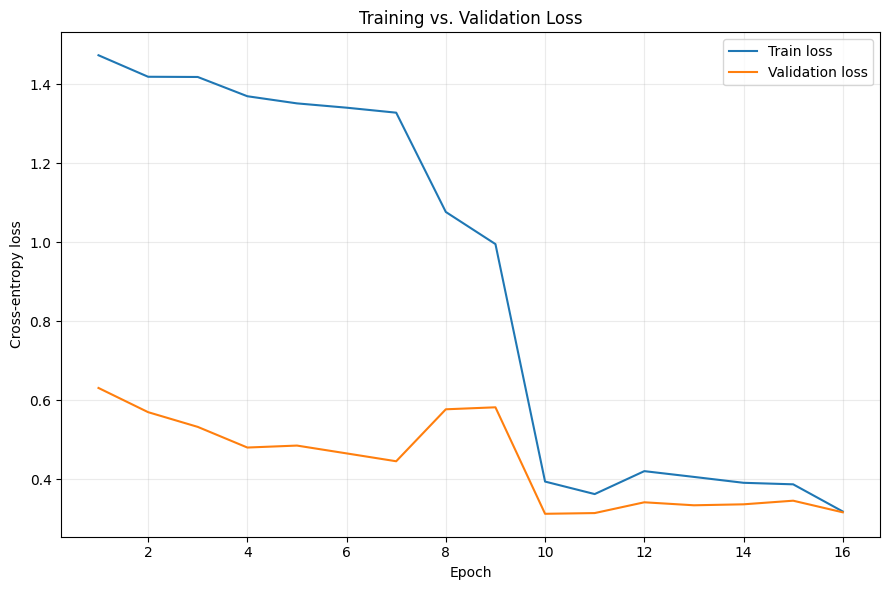

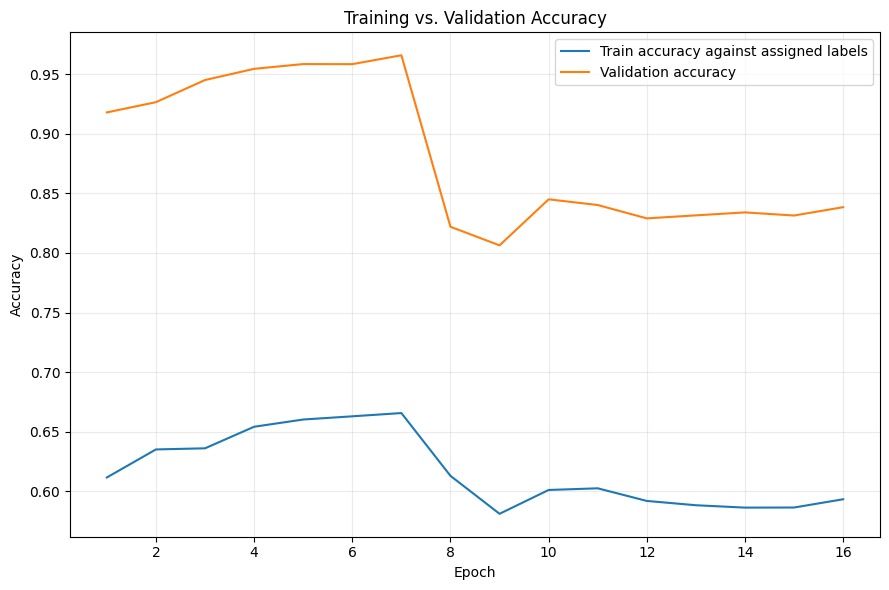

In [13]:
# =============================================================================
# SECTION 11 — Train-versus-validation loss and accuracy graphs
# =============================================================================

HISTORY_TABLE = pd.DataFrame(HISTORY)
HISTORY_TABLE.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

plt.figure(figsize=(9, 6))
plt.plot(HISTORY_TABLE["epoch"], HISTORY_TABLE["train_loss"], label="Train loss")
plt.plot(
    HISTORY_TABLE["epoch"],
    HISTORY_TABLE["validation_loss"],
    label="Validation loss",
)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training vs. Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "train_vs_validation_loss.png", dpi=300)
plt.show()
plt.close()

plt.figure(figsize=(9, 6))
plt.plot(
    HISTORY_TABLE["epoch"],
    HISTORY_TABLE["train_accuracy_against_assigned_labels"],
    label="Train accuracy against assigned labels",
)
plt.plot(
    HISTORY_TABLE["epoch"],
    HISTORY_TABLE["validation_accuracy"],
    label="Validation accuracy",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs. Validation Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "train_vs_validation_accuracy.png", dpi=300)
plt.show()
plt.close()



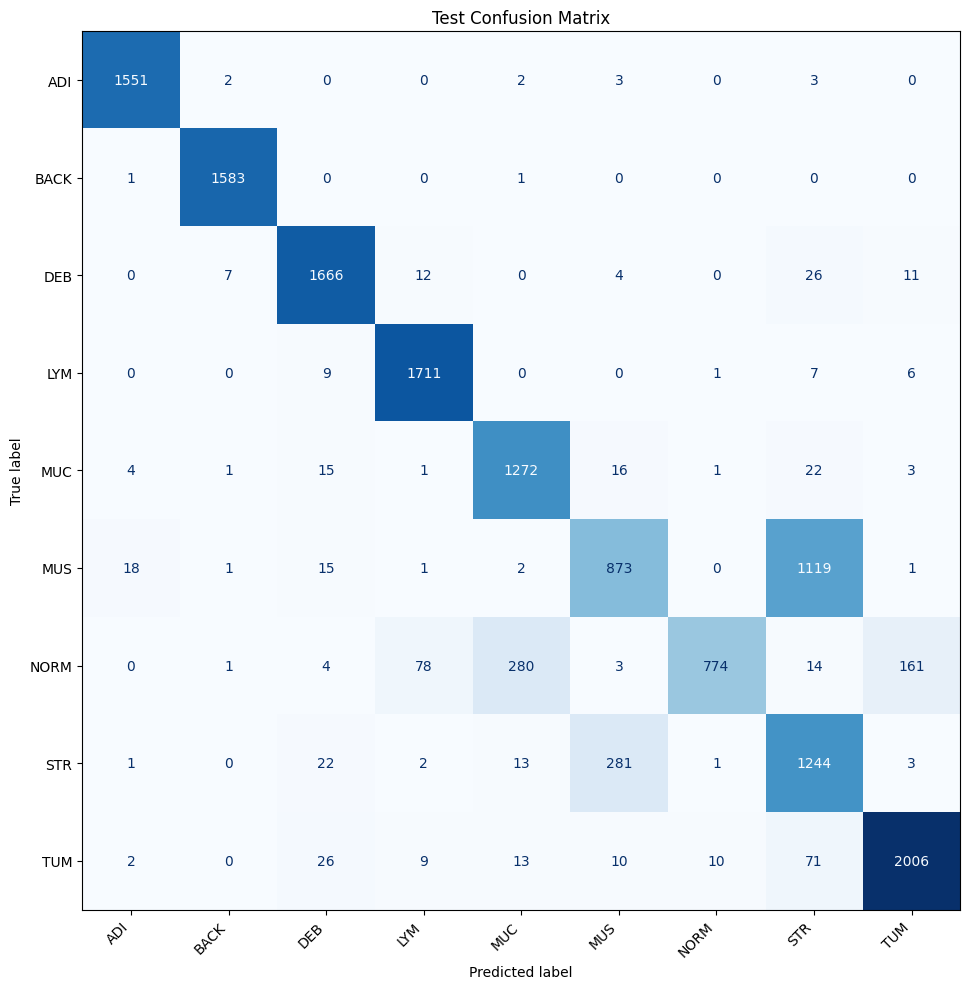

In [14]:
# =============================================================================
# SECTION 12 — Test confusion matrix
# =============================================================================

TEST_CONFUSION_MATRIX = confusion_matrix(
    Y_TEST,
    Y_PRED,
    labels=np.arange(NUM_CLASSES),
)

figure, axis = plt.subplots(figsize=(11, 10))
display = ConfusionMatrixDisplay(
    confusion_matrix=TEST_CONFUSION_MATRIX,
    display_labels=CLASS_NAMES,
)
display.plot(ax=axis, cmap="Blues", values_format="d", colorbar=False)
axis.set_title("Test Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "test_confusion_matrix.png", dpi=300)
plt.show()
plt.close()

pd.DataFrame(
    TEST_CONFUSION_MATRIX,
    index=[f"True_{name}" for name in CLASS_NAMES],
    columns=[f"Predicted_{name}" for name in CLASS_NAMES],
).to_csv(OUTPUT_DIR / "test_confusion_matrix.csv")



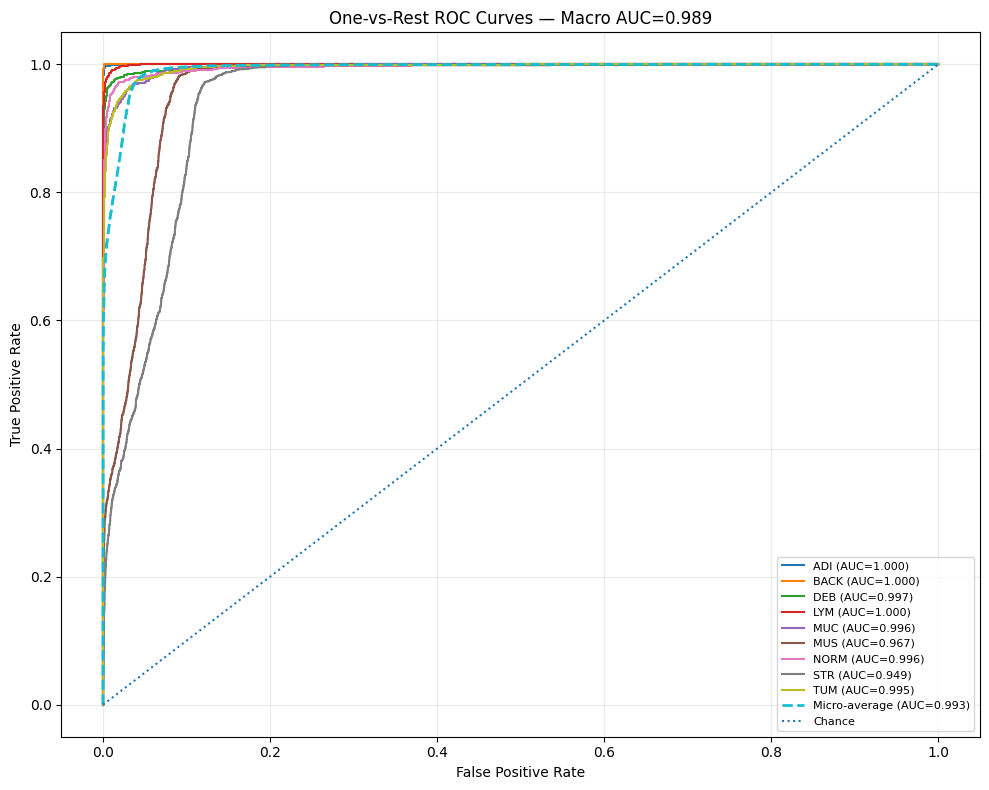


Per-class ROC-AUC:
    Class  ROC_AUC_OVR
0     ADI       0.9999
1    BACK       1.0000
2     DEB       0.9973
3     LYM       0.9996
4     MUC       0.9957
5     MUS       0.9673
6    NORM       0.9957
7     STR       0.9494
8     TUM       0.9955
9   MACRO       0.9889
10  MICRO       0.9929


In [15]:
# =============================================================================
# SECTION 13 — Multiclass one-vs-rest ROC curves and macro ROC-AUC
# =============================================================================

Y_TEST_BINARIZED = label_binarize(Y_TEST, classes=np.arange(NUM_CLASSES))

class_fpr: Dict[int, np.ndarray] = {}
class_tpr: Dict[int, np.ndarray] = {}
class_auc: Dict[int, float] = {}

plt.figure(figsize=(10, 8))
for class_index, class_name in enumerate(CLASS_NAMES):
    class_fpr[class_index], class_tpr[class_index], _ = roc_curve(
        Y_TEST_BINARIZED[:, class_index],
        Y_PROB[:, class_index],
    )
    class_auc[class_index] = auc(class_fpr[class_index], class_tpr[class_index])
    plt.plot(
        class_fpr[class_index],
        class_tpr[class_index],
        linewidth=1.5,
        label=f"{class_name} (AUC={class_auc[class_index]:.3f})",
    )

micro_fpr, micro_tpr, _ = roc_curve(Y_TEST_BINARIZED.ravel(), Y_PROB.ravel())
micro_auc = auc(micro_fpr, micro_tpr)
macro_auc = roc_auc_score(
    Y_TEST,
    Y_PROB,
    multi_class="ovr",
    average="macro",
    labels=np.arange(NUM_CLASSES),
)

plt.plot(
    micro_fpr,
    micro_tpr,
    linestyle="--",
    linewidth=2.0,
    label=f"Micro-average (AUC={micro_auc:.3f})",
)
plt.plot([0, 1], [0, 1], linestyle=":", linewidth=1.5, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"One-vs-Rest ROC Curves — Macro AUC={macro_auc:.3f}")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "test_multiclass_roc_auc.png", dpi=300)
plt.show()
plt.close()

ROC_AUC_TABLE = pd.DataFrame(
    {
        "Class": CLASS_NAMES,
        "ROC_AUC_OVR": [class_auc[index] for index in range(NUM_CLASSES)],
    }
)
ROC_AUC_TABLE.loc[len(ROC_AUC_TABLE)] = ["MACRO", macro_auc]
ROC_AUC_TABLE.loc[len(ROC_AUC_TABLE)] = ["MICRO", micro_auc]
ROC_AUC_TABLE.to_csv(OUTPUT_DIR / "test_roc_auc_by_class.csv", index=False)

print("\nPer-class ROC-AUC:")
print(ROC_AUC_TABLE.round(4))



In [16]:
# =============================================================================
# SECTION 14 — Final reproducibility checks and generated-output inventory
# =============================================================================

assert len(TRAIN_PATHS) + len(VALIDATION_PATHS) + len(TEST_PATHS) == len(ALL_PATHS)
assert np.isclose(TRUE_FLIP_MASK.mean(), CFG.label_flip_rate, atol=1.0 / len(TRAIN_PATHS))
assert Y_PROB.shape == (len(TEST_PATHS), NUM_CLASSES)
assert np.allclose(Y_PROB.sum(axis=1), 1.0, atol=1e-4)
assert len(Y_TEST) == len(TEST_PATHS)
assert len(Y_PRED) == len(TEST_PATHS)

print("\nAll final integrity checks passed.")
print(f"All outputs were saved to: {OUTPUT_DIR}")
print("Generated files:")
for generated_file in sorted(OUTPUT_DIR.iterdir()):
    print(f" - {generated_file.name}")


All final integrity checks passed.
All outputs were saved to: /kaggle/working/tc_gpa_outputs
Generated files:
 - best_tc_gpa_model.pt
 - configuration.json
 - split_class_counts.csv
 - tc_gpa_sample_level_audit.csv
 - tc_gpa_update_metrics.csv
 - test_classification_report.csv
 - test_confusion_matrix.csv
 - test_confusion_matrix.png
 - test_multiclass_roc_auc.png
 - test_roc_auc_by_class.csv
 - test_summary.json
 - train_vs_validation_accuracy.png
 - train_vs_validation_loss.png
 - training_flip_summary.csv
 - training_flip_transition_matrix.csv
 - training_history.csv
 - training_label_flip_audit.csv
